In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

### Scalar Clenshaw algorithm

In [12]:
def clenshaw_legendre_scalar(x, coefs):
    """
    Evaluate a Legendre series using Clenshaw's recursion.
    :param coefs: Coefficients of the polynomial in Clenshaw form.
    :param x: Scalar value at which to evaluate the polynomial.
    :return: Evaluated polynomial value.
    """
    n = coefs.shape[0]
    b2 = 0
    b1 = 0
    for k in reversed(range(n)):
        alpha = (2*k + 1) / (k + 1)
        beta = (k + 1) / (k + 2)
        bnext = coefs[k] + alpha * x * b1 - beta * b2
        b2, b1 = b1, bnext
    return b1

### Batch Clenshaw algorithm for a batch of inputs

In [75]:
def clenshaw_batch(x, coefs):
    """
    Evaluate a Legendre series using Clenshaw's recursion for a batch of inputs.
    :param coefs: Coefficients of the polynomial in Clenshaw form.
    :param x: Batch of scalar values at which to evaluate the polynomial.
    :return: Evaluated polynomial values for each input in the batch.
    """
    n = coefs.shape[0]
    b2 = torch.zeros_like(x)
    b1 = torch.zeros_like(x)
    for k in reversed(range(n)):
        alpha = (2*k + 1) / (k + 1)
        beta = (k + 1) / (k + 2)
        bnext = coefs[k] + alpha * x * b1 - beta * b2
        b2, b1 = b1, bnext
    return b1

In [76]:
coefs = np.cos(np.linspace(0, 10, 100))
x = np.linspace(-1, 1, 10)

In [80]:
np.polynomial.legendre.legval(x, coefs)

array([ 0.90578617,  0.5155577 ,  0.52687089,  0.57255943,  0.70542426,
        0.72346426,  0.85290285,  1.05995007,  1.62732163, -5.30076468])

In [81]:
clenshaw_batch(torch.as_tensor(x), torch.as_tensor(coefs))

tensor([ 0.9058,  0.5156,  0.5269,  0.5726,  0.7054,  0.7235,  0.8529,  1.0600,
         1.6273, -5.3008], dtype=torch.float64)

### Batch Clenshaw with vector coefficients - one curve

In [ ]:
def legendre_batch_curve(x, coefs):
    """
    Evaluate a Legendre series using Clenshaw's recursion for a batch of inputs
    :param coefs:
        Matrix of size (n, m) of curve coefficients, of an m-dimensional polynomil curve of degree n-1, represented
        in the Legendre basis.
    :param x: Batch of scalar values at which to evaluate the polynomial.
    :return: Evaluated polynomial values for each input in the batch.
    """
    n, m = coefs.shape       # n - number of coefficients, m - number of polynomials
    x = x.unsqueeze(1).expand(-1, m) # (b x m), b = batch size
    b2 = torch.zeros_like(x)         # (b x m)
    b1 = torch.zeros_like(x)         # (b x m)
    for k in reversed(range(n)):
        alpha = (2*k + 1) / (k + 1)
        beta = (k + 1) / (k + 2)
        curr_coef = coefs[k].unsqueeze(0)  # (1 x m)
        bnext = curr_coef + alpha * x * b1 - beta * b2
        b2, b1 = b1, bnext
    return b1

In [ ]:
coef_mat = torch.as_tensor(np.stack([coefs, 2 * coefs], axis=-1))
legendre_batch_curve(torch.as_tensor(x), coef_mat)

tensor([[  0.9058,   1.8116],
        [  0.5156,   1.0311],
        [  0.5269,   1.0537],
        [  0.5726,   1.1451],
        [  0.7054,   1.4108],
        [  0.7235,   1.4469],
        [  0.8529,   1.7058],
        [  1.0600,   2.1199],
        [  1.6273,   3.2546],
        [ -5.3008, -10.6015]], dtype=torch.float64)

In [ ]:
legendre_batch_curve(torch.as_tensor(x), torch.as_tensor(coef_mat[:, 0]))

tensor([ 0.9058,  0.5156,  0.5269,  0.5726,  0.7054,  0.7235,  0.8529,  1.0600,
         1.6273, -5.3008], dtype=torch.float64)

In [ ]:
legendre_batch_curve(torch.as_tensor(x), torch.as_tensor(coef_mat[:, 1]))

tensor([  1.8116,   1.0311,   1.0537,   1.1451,   1.4108,   1.4469,   1.7058,
          2.1199,   3.2546, -10.6015], dtype=torch.float64)

### Batch Clenshaw with multiple curves

In [109]:
def legendre_batch_curves(x, coefs):
    """
    Evaluate a Legendre series using Clenshaw's recursion for a batch of inputs
    :param coefs:
        Tensor of size (n, c, m) of curve coefficients, of a set of c polynomial curves in m dimensions of degree n-1,
        represented in the Legendre basis.
    :param x: Batch of size (b, c), x[:, j] is the batch of inputs for the j-th curve in the batch.
    :return: Tensor of size (b, c, m) of the batch points on c curves in m-dimensions.
    """
    n, c, m = coefs.shape       # n - number of coefficients, c - number of curves, m - curve dimension
    x = x.unsqueeze(-1).expand(-1, -1, m) # (b × c × m), b = batch size
    b2 = torch.zeros_like(x)              # (b × c × m)
    b1 = torch.zeros_like(x)              # (b × c × m)
    for k in reversed(range(n)):
        alpha = (2*k + 1) / (k + 1)
        beta = (k + 1) / (k + 2)
        curr_coef = coefs[k].unsqueeze(0)  # (1 x c x m)
        bnext = curr_coef + alpha * x * b1 - beta * b2
        b2, b1 = b1, bnext
    return b1

In [ ]:
n = 1000  # polynomial degree + 1
c = 10    # number of curves
m = 384   # curve dimension
b = 20    # batch size

coefs = torch.randn(n, c, m, dtype=torch.float32)
x = 2 * torch.rand(b, c, dtype=torch.float32) - 1

Max difference: 3.738130321393279e-13


(array([2.751e+03, 7.350e+02, 1.600e+02, 6.400e+01, 3.600e+01, 3.300e+01,
        1.500e+01, 1.100e+01, 1.000e+01, 9.000e+00, 5.000e+00, 4.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 2.000e+00,
        1.000e+00, 1.000e+00]),
 array([6.19695673e-15, 2.45777605e-14, 4.29585643e-14, 6.13393680e-14,
        7.97201718e-14, 9.81009756e-14, 1.16481779e-13, 1.34862583e-13,
        1.53243387e-13, 1.71624191e-13, 1.90004994e-13, 2.08385798e-13,
        2.26766602e-13, 2.45147406e-13, 2.63528210e-13, 2.81909013e-13,
        3.00289817e-13, 3.18670621e-13, 3.37051425e-13, 3.55432228e-13,
        3.73813032e-13]),
 <BarContainer object of 20 artists>)

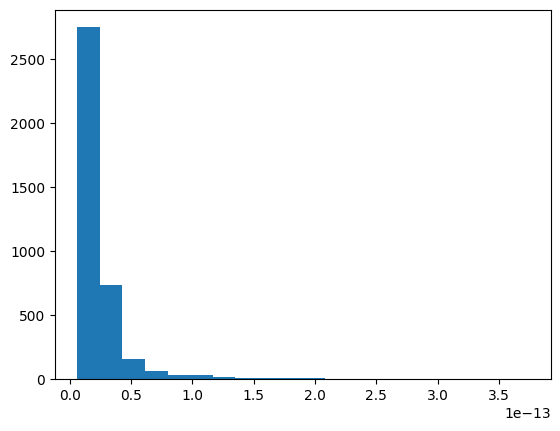

In [180]:
torch_eval = legendre_batch_curves(x, coefs)
diffs = []
for ci in range(c):
    for mi in range(m):
        coef_np = coefs[:, ci, mi].numpy()
        x_vals = x[:, ci].numpy()
        vals = np.polynomial.legendre.legval(x_vals, coef_np)
        torch_vals = torch_eval[:, ci, mi].numpy()
        diff = np.linalg.norm(vals - torch_vals)
        diffs.append(diff)

print(f"Max difference: {np.max(diffs)}")
plt.hist(diffs, bins=20)